In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("forestfires.csv")

# Display information
print(df.info())
print(df.describe())
print(df.head())

## Dataset Overview

The dataset contains 517 observations and 13 variables.

### Data Types
- Numerical Variables: X, Y, FFMC, DMC, DC, ISI, temp, RH, wind, rain, area
- Categorical Variables: month, day

### Missing Values
There are no missing values in the dataset.

### Target Variable
The target variable is:

- area: Represents the burned area of the forest fire.

### Initial Observations
The dataset contains environmental and weather-related variables that may influence wildfire severity. Since month and day are categorical variables, they will require encoding during preprocessing.

In [ ]:
# Step 2: Exploratory Data Analysis (EDA)
# Missing Values

df.isnull().sum()

## Missing Value Assessment

The dataset contains no missing values.

This indicates:
- No imputation is necessary.
- No observations need to be removed.
- Analysis can proceed directly to exploration and modeling.

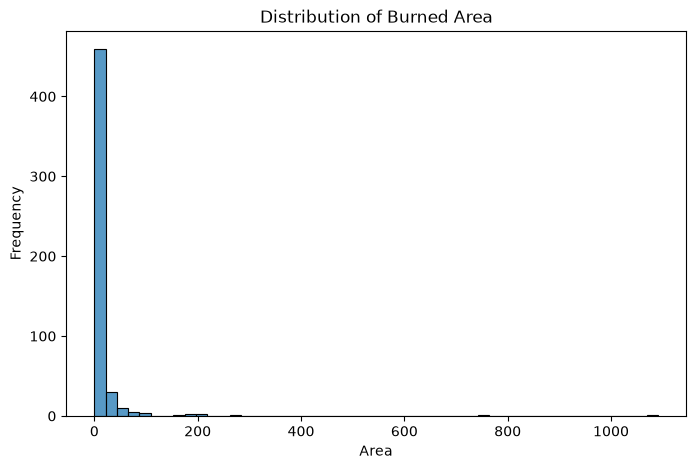

Skewness: 12.846933533934868


In [12]:
# Target Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['area'], bins=50)

plt.title("Distribution of Burned Area")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

print("Skewness:", df['area'].skew())

## Interpretation

The burned area variable is expected to display significant right skewness.

This means:
- Most fires affect small areas.
- A few fires affect extremely large areas.
- Outliers are likely present.

A logarithmic transformation may improve the performance of regression models by reducing the influence of extreme observations.

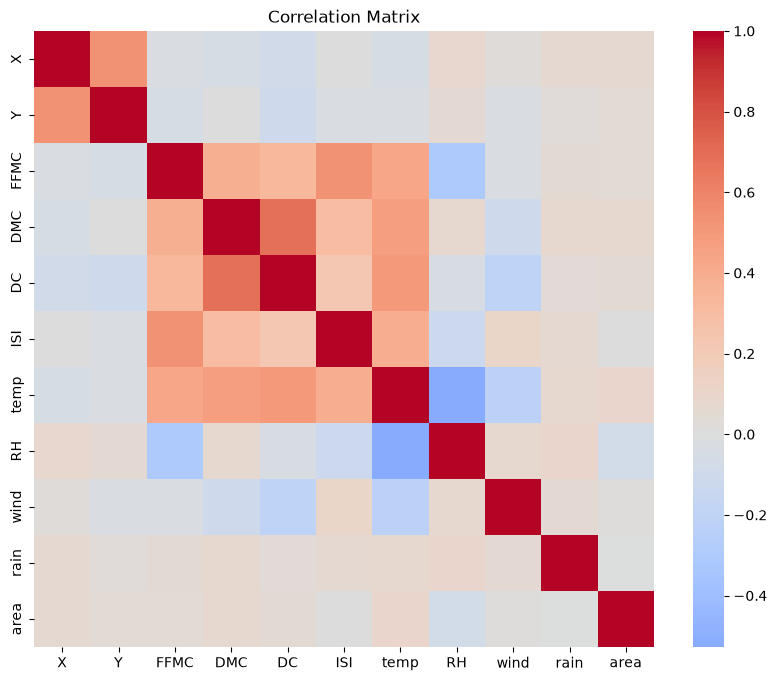

In [13]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Correlation Analysis

The correlation matrix identifies relationships among variables.

Positive correlations indicate variables that increase together.

Negative correlations indicate inverse relationships.

Variables showing stronger correlations with area are potential predictors of wildfire severity.

Strong correlations among predictors may indicate multicollinearity, which will be investigated later using VIF.

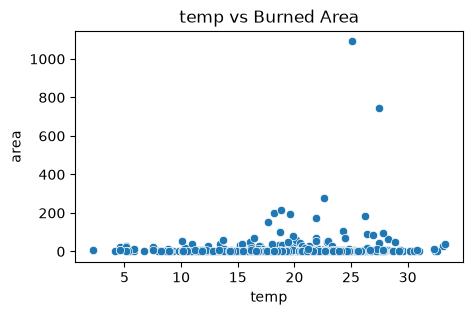

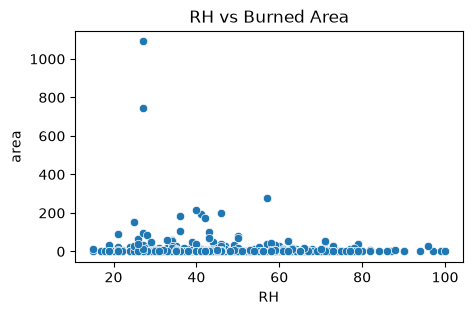

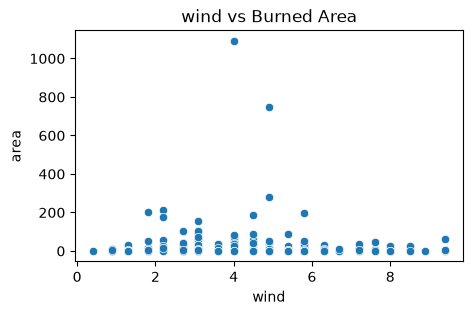

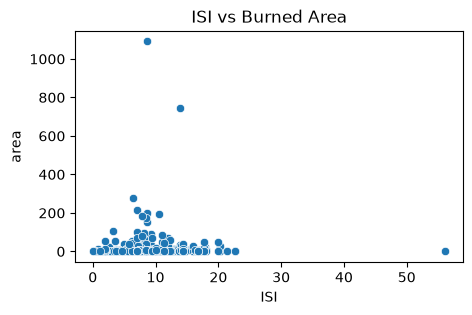

In [14]:
# Scatterplots

key_features = ['temp','RH','wind','ISI']

for col in key_features:
    
    plt.figure(figsize=(5,3))
    
    sns.scatterplot(
        x=df[col],
        y=df['area']
    )
    
    plt.title(f"{col} vs Burned Area")
    
    plt.show()

## Interpretation

These visualizations help identify relationships between environmental variables and burned area.

Potential expectations:

- Higher temperatures may be associated with increased fire severity.
- Higher humidity may reduce fire spread.
- Strong winds may contribute to larger fires.
- Increased fire danger indices may correspond to greater burned areas.

Scatterplots also reveal outliers and possible nonlinear relationships.

In [15]:
# Step 3: Feature Engineering
# Create Dummy Variables

df = pd.get_dummies(
    df,
    columns=['month','day'],
    drop_first=True
)

df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,False,False,False,False,False,False,False,False,False,False
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,False,False,True,False,False,False,False,False,True,False
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,False,False,True,False,False,True,False,False,False,False
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,False,False,False,False,False,False,False,False,False,False
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,False,False,False,False,False,False,True,False,False,False


## Feature Engineering

The categorical variables month and day have been converted into dummy variables.

This enables regression algorithms to process categorical information correctly while avoiding the dummy variable trap.

In [16]:
# Step 4: Regression Models
# Baseline Model

import statsmodels.api as sm

features = ['temp','RH','wind',
            'ISI','FFMC','DMC','DC']

X_base = sm.add_constant(df[features])

baseline_model = sm.OLS(
    df['area'],
    X_base
).fit()

print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.173
Date:               Thu, 24 Sept 2026   Prob (F-statistic):              0.316
Time:                        19:57:23   Log-Likelihood:                -2876.3
No. Observations:                 517   AIC:                             5769.
Df Residuals:                     509   BIC:                             5803.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2767     61.619      0.069      0.9

## Baseline Regression Interpretation

Important outputs include:

### R²
Represents the proportion of variance explained by the predictors.

### Adjusted R²
Adjusts model performance for the number of predictors included.

### P-values
Predictors with p-values less than 0.05 may be considered statistically significant.

### Coefficients
Positive coefficients indicate an increase in burned area as the predictor increases.

Negative coefficients indicate a decrease in burned area as the predictor increases.

In [17]:
# Log Transformation

df['log_area'] = np.log1p(df['area'])

log_model = sm.OLS(
    df['log_area'],
    X_base
).fit()

print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.445
Date:               Thu, 24 Sept 2026   Prob (F-statistic):              0.185
Time:                        19:58:53   Log-Likelihood:                -901.38
No. Observations:                 517   AIC:                             1819.
Df Residuals:                     509   BIC:                             1853.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1547      1.351      0.114      0.9

## Log-Transformed Model Interpretation

The logarithmic transformation reduces the impact of extremely large fires.

Benefits include:

- Reduced skewness
- Improved normality
- Better residual behaviour
- More stable coefficient estimates

This model is expected to outperform the baseline regression model.

In [18]:
# Quadratic Model

df['temp_sq'] = df['temp']**2

features_quad = features + ['temp_sq']

X_quad = sm.add_constant(
    df[features_quad]
)

quad_model = sm.OLS(
    df['log_area'],
    X_quad
).fit()

print(quad_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     2.621
Date:               Thu, 24 Sept 2026   Prob (F-statistic):            0.00808
Time:                        20:01:17   Log-Likelihood:                -896.01
No. Observations:                 517   AIC:                             1810.
Df Residuals:                     508   BIC:                             1848.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7244      1.350      0.537      0.5

## Quadratic Term Interpretation

The squared temperature term allows the model to capture nonlinear effects.

If the temperature squared term is significant, it suggests that temperature may influence wildfire severity in a nonlinear manner rather than through a simple linear relationship.

In [19]:
# Interaction Model

df['temp_RH'] = (
    df['temp'] * df['RH']
)

features_inter = (
    features_quad + ['temp_RH']
)

X_inter = sm.add_constant(
    df[features_inter]
)

interaction_model = sm.OLS(
    df['log_area'],
    X_inter
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     2.640
Date:               Thu, 24 Sept 2026   Prob (F-statistic):            0.00541
Time:                        20:02:33   Log-Likelihood:                -894.63
No. Observations:                 517   AIC:                             1809.
Df Residuals:                     507   BIC:                             1852.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4809      1.718      1.444      0.1

## Interaction Term Interpretation

The interaction term examines whether the effect of temperature depends on humidity.

A significant interaction suggests that wildfire risk is driven by combinations of climatic conditions rather than individual variables alone.

In [20]:
# Step 5: Compare Regression Models

comparison = pd.DataFrame({

    'Model':[
        'Baseline',
        'Log',
        'Quadratic',
        'Interaction'
    ],

    'R2':[
        baseline_model.rsquared,
        log_model.rsquared,
        quad_model.rsquared,
        interaction_model.rsquared
    ],

    'Adj_R2':[
        baseline_model.rsquared_adj,
        log_model.rsquared_adj,
        quad_model.rsquared_adj,
        interaction_model.rsquared_adj
    ],

    'AIC':[
        baseline_model.aic,
        log_model.aic,
        quad_model.aic,
        interaction_model.aic
    ],

    'BIC':[
        baseline_model.bic,
        log_model.bic,
        quad_model.bic,
        interaction_model.bic
    ]
})

comparison

,Model,R2,Adj_R2,AIC,BIC
0,Baseline,0.015879,0.002345,5768.615383,5802.599726
1,Log,0.019482,0.005997,1818.766418,1852.750761
2,Quadratic,0.039646,0.024522,1810.023851,1848.256237
3,Interaction,0.044759,0.027802,1809.263838,1851.744267


## Model Comparison

The preferred model should demonstrate:

- Higher Adjusted R²
- Lower AIC
- Lower BIC

The strongest model balances predictive performance and interpretability.

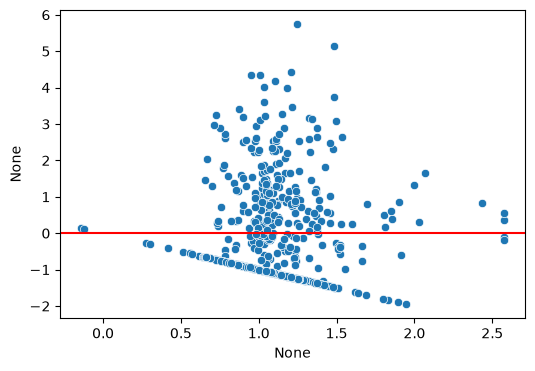

In [21]:
# Step 6: Model Diagnostics
# Residual Plot

residuals = interaction_model.resid

fitted = interaction_model.fittedvalues

plt.figure(figsize=(6,4))

sns.scatterplot(
    x=fitted,
    y=residuals
)

plt.axhline(
    0,
    color='red'
)

plt.show()

## Residual Plot Interpretation

A good model should produce residuals that:

- Scatter randomly around zero.
- Show no systematic patterns.
- Display approximately constant variance.

Random residuals support model adequacy.

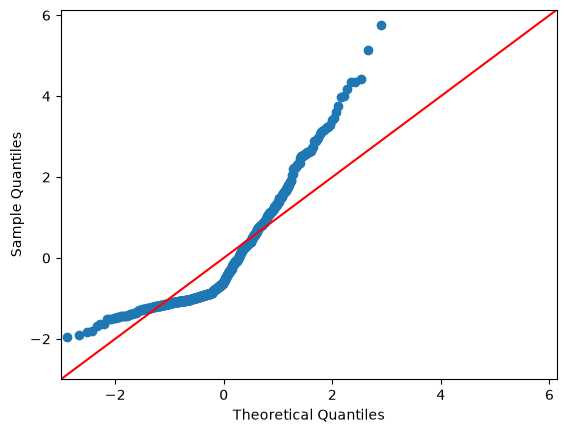

In [22]:
# Q-Q Plot

sm.qqplot(
    residuals,
    line='45'
)

plt.show()

## Q-Q Plot Interpretation

Points following the diagonal line suggest that residuals are approximately normally distributed.

Substantial departures from the line indicate possible violations of the normality assumption.

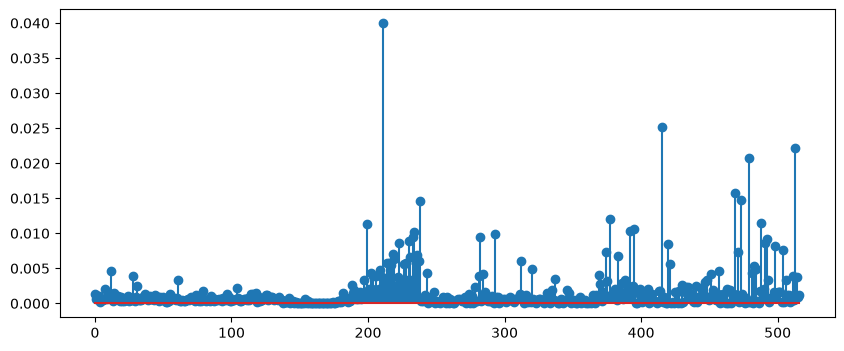

In [23]:
# Cook's Distance

influence = interaction_model.get_influence()

cooks = influence.cooks_distance[0]

plt.figure(figsize=(10,4))

plt.stem(cooks)

plt.show()

## Cook's Distance Interpretation

Cook's Distance identifies influential observations.

Observations exceeding 4/n may have a disproportionate impact on model estimates and should be examined further.

In [26]:
# Step 7: Ridge and Lasso Regression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_ml = df[features_inter]
y_ml = df['log_area']

X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Ridge

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=1)

ridge.fit(
    X_train_scaled,
    y_train
)

ridge_pred = ridge.predict(
    X_test_scaled
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)

print("Ridge MSE:", ridge_mse)

Ridge MSE: 2.127526785393


In [28]:
# Lasso

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(
    X_train_scaled,
    y_train
)

lasso_pred = lasso.predict(
    X_test_scaled
)

lasso_mse = mean_squared_error(
    y_test,
    lasso_pred
)

print("Lasso MSE:", lasso_mse)

Lasso MSE: 2.147717037157317


## Regularization Interpretation

Ridge Regression:
- Retains all variables.
- Reduces coefficient size.

Lasso Regression:
- May shrink coefficients to zero.
- Performs feature selection.

The model with the lower MSE provides better predictive accuracy.

In [30]:
# Step 8: Logistic Regression
# Create Binary Target

median_area = df['area'].median()

df['high_risk'] = (
    df['area'] > median_area
).astype(int)

df['high_risk'].value_counts()

high_risk
0    259
1    258
Name: count, dtype: int64

In [31]:
# Train Model

from sklearn.linear_model import LogisticRegression

X_class = df[features]

y_class = df['high_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [32]:
# Evaluate

from sklearn.metrics import *

y_pred = log_model.predict(
    X_test_scaled
)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.4807692307692308
Precision: 0.48333333333333334
Recall: 0.5576923076923077
F1: 0.5178571428571429
[[21 31]
 [23 29]]


## Logistic Regression Interpretation

Accuracy measures overall prediction correctness.

Precision measures the proportion of predicted high-risk fires that were actually high risk.

Recall measures the proportion of actual high-risk fires successfully identified.

F1-score balances precision and recall.

A higher F1-score indicates a stronger classification model.

In [33]:
# Step 9: Variance Inflation Factor (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df['Feature'] = X_ml.columns

vif_df['VIF'] = [
    variance_inflation_factor(
        X_ml.values,
        i
    )
    for i in range(X_ml.shape[1])
]

vif_df.sort_values(
    'VIF',
    ascending=False
)

,Feature,VIF
0,temp,68.280369
7,temp_sq,34.837405
1,RH,12.412890
8,temp_RH,11.270274
5,DMC,2.349840
6,DC,2.173870
4,FFMC,1.794325
3,ISI,1.621912
2,wind,1.206597


## VIF Interpretation

VIF Values:

- Below 5: Acceptable
- Between 5 and 10: Moderate multicollinearity
- Greater than 10: Strong multicollinearity

High VIF values may explain unstable coefficients and justify the use of Ridge and Lasso Regression.

In [ ]:
# Step 10: Final Findings

# Summative Findings

The Forest Fires dataset was analyzed to investigate the environmental and weather conditions associated with wildfire severity.

Exploratory Data Analysis revealed no missing values and identified substantial right skewness in the burned area variable. This motivated the application of a logarithmic transformation to improve model performance.

Several regression models were evaluated, including baseline, transformed, quadratic, and interaction models. Model diagnostics indicated that transformed models provided better behaviour with respect to residual patterns and normality assumptions.

Regularization techniques were used to address multicollinearity and improve generalization. Ridge retained all predictors while shrinking coefficients, whereas Lasso improved interpretability through feature selection.

A Logistic Regression classifier was developed to identify high-risk fire events. The model was evaluated using accuracy, precision, recall, and F1-score to assess classification performance.

Overall, temperature, humidity, wind speed, and fire danger indices appear to be influential predictors of wildfire behaviour. These findings can support forestry managers in resource allocation, early warning systems, and wildfire prevention strategies.